In [51]:
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

In [52]:
df = sns.load_dataset('titanic')

df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [53]:
df.drop('deck', axis=1, inplace=True)
df.drop('alive', axis=1, inplace=True)

df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['age'] = KNNImputer().fit_transform(df[['age']])


categorical_cols = df.select_dtypes(include=['category', 'object']).columns
df[categorical_cols] = df[categorical_cols].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    category
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    category
 12  alone        891 non-null    bool    
dtypes: bool(2), category(5), float64(2), int64(4)
memory usage: 48.6 KB


In [54]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [55]:
model = CatBoostClassifier(
    iterations=1000,
    eval_metric='Accuracy',
    learning_rate=0.001,
    depth=5,
    loss_function='Logloss',
    random_state=0,
    verbose=False
)

model.fit(X_train, y_train, cat_features=categorical_cols.tolist())

y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Classification Report: \n{classification_report(y_test, y_pred)}")

Accuracy Score: 0.8156424581005587
Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



<Axes: >

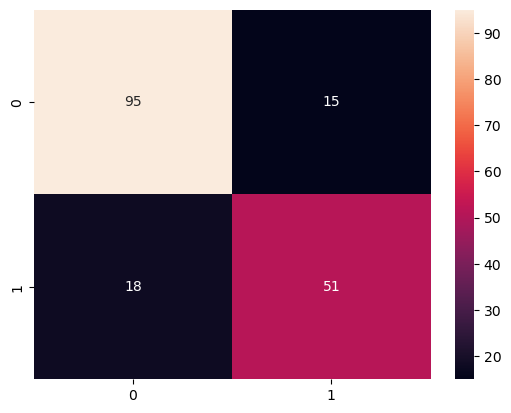

In [56]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

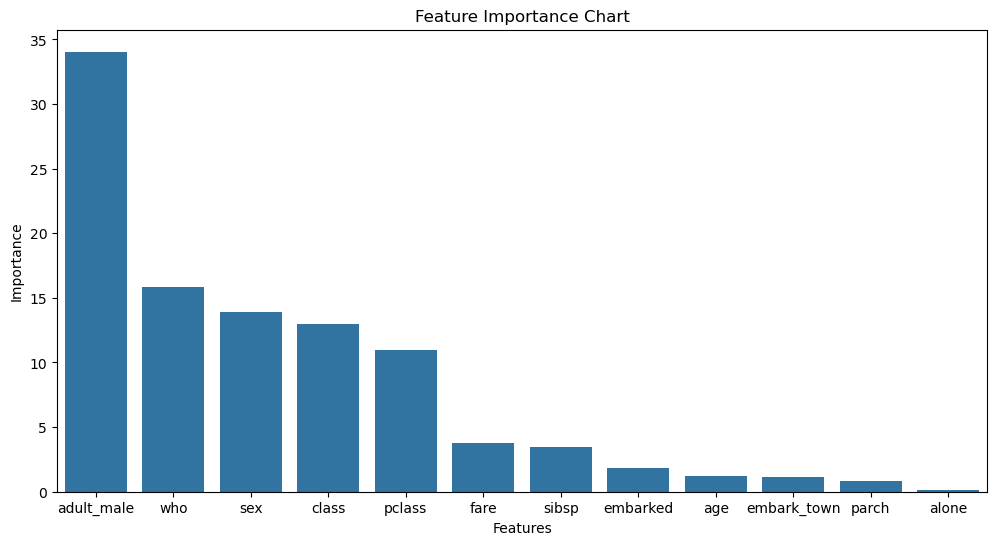

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature Id', y='Importances', data=model.get_feature_importance(prettified=True))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance Chart')
plt.show()